In [1]:
%pip install numpy matplotlib ipywidgets pandas openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

In [3]:
AFM_FOLDER = Path("afm_data")

EXCEL_FOLDER = Path("afm_values")

DEFAULT_X_MIN = -150

DEFAULT_X_MAX = 200


# ============================================================
# JPK LINEAR AND ELASTICITY FIT OVERLAY
# Add this as a NEW CELL at the bottom of main.ipynb
# ============================================================

# This cell uses functions and variables already defined
# earlier in main.ipynb:
#
# AFM_FOLDER
# load_afm_txt()
# get_curve_values()
# format_value()
# redraw_plot()
#
# No Plotly is used here.
# This is Matplotlib only.
# ============================================================


# ============================================================
# JPK FIT SETTINGS
# ============================================================

JPK_LINEAR_BOUNDARY_NM = -25.0

JPK_POISSON_RATIO = 0.50

JPK_PYRAMID_HALF_ANGLE_DEG = 20.0

JPK_ELASTICITY_PLOT_POINTS = 150


# ============================================================
# CACHE FOR TSV FILES
# ============================================================

jpk_tsv_cache = {}


# ============================================================
# EXTRACT cropped_XX NUMBER FROM ANY FILENAME
# ============================================================

def extract_cropped_number_from_name(name):

    match = re.search(
        r"cropped_(\d+)",
        str(name),
        re.IGNORECASE
    )

    if match is None:

        return None

    return int(
        match.group(1)
    )


# ============================================================
# READ A VALUE FROM TXT HEADER
# ============================================================

def read_txt_header_value(
    file_path,
    key
):

    prefix = (
        f"# {key}:"
    )

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as file:

        for line in file:

            if line.startswith(
                prefix
            ):

                return (
                    line
                    .split(
                        ":",
                        1
                    )[1]
                    .strip()
                )

    return None


# ============================================================
# FIND JPK BATCH TSV
# ============================================================

def find_jpk_tsv(
    file_path
):

    file_path = Path(
        file_path
    )

    folder = (
        file_path.parent
    )


    # --------------------------------------------------------
    # First look inside the same AFM folder
    # --------------------------------------------------------

    candidates = sorted(
        folder.glob(
            "*processed*.tsv"
        )
    )


    if len(candidates) > 0:

        return candidates[-1]


    # --------------------------------------------------------
    # If not found, identify acquisition prefix
    #
    # Example:
    #
    # qi-data-2024.10.02-12.34.24.687-cropped_14.txt
    #
    # becomes:
    #
    # qi-data-2024.10.02-12.34.24.687
    # --------------------------------------------------------

    filename = (
        file_path.name
    )


    if "-cropped_" in filename:

        acquisition_prefix = (
            filename.split(
                "-cropped_",
                1
            )[0]
        )

    else:

        acquisition_prefix = None


    # --------------------------------------------------------
    # Search all AFM folders as fallback
    # --------------------------------------------------------

    if acquisition_prefix:

        all_tsv = sorted(
            AFM_FOLDER.rglob(
                "*processed*.tsv"
            )
        )


        matching = [

            path

            for path
            in all_tsv

            if path.name.startswith(
                acquisition_prefix
            )

        ]


        if len(matching) > 0:

            return matching[-1]


    return None


# ============================================================
# LOAD JPK BATCH TSV
# ============================================================

def load_jpk_batch_table(
    file_path
):

    tsv_file = find_jpk_tsv(
        file_path
    )


    if tsv_file is None:

        return None, None


    cache_key = str(
        tsv_file.resolve()
    )


    if cache_key not in jpk_tsv_cache:

        df = pd.read_csv(
            tsv_file,
            sep="\t"
        )


        required_columns = [

            "Filename",

            "Slope [N/m]",

            "Young's Modulus [Pa]",

            "Contact Point [m]",

            "Baseline [N]",

            "ResidualRMS [N]"

        ]


        missing = [

            column

            for column
            in required_columns

            if column
            not in df.columns

        ]


        if len(missing) > 0:

            raise ValueError(

                f"Missing columns in "
                f"{tsv_file.name}: "
                f"{missing}"

            )


        df = df.copy()


        df[
            "_curve_number"
        ] = (

            df["Filename"]
            .apply(
                extract_cropped_number_from_name
            )

        )


        jpk_tsv_cache[
            cache_key
        ] = df


    return (
        jpk_tsv_cache[
            cache_key
        ],
        tsv_file
    )


# ============================================================
# RECONSTRUCT JPK LINEAR AND ELASTICITY FIT
# ============================================================

def reconstruct_jpk_fit(
    file_path,
    approach
):

    # --------------------------------------------------------
    # Load corresponding TSV
    # --------------------------------------------------------

    batch_df, tsv_file = (
        load_jpk_batch_table(
            file_path
        )
    )


    if batch_df is None:

        return None


    if approach.size == 0:

        return None


    # --------------------------------------------------------
    # Find curve number
    # --------------------------------------------------------

    curve_number = (
        extract_cropped_number_from_name(
            Path(file_path).name
        )
    )


    if curve_number is None:

        return None


    # --------------------------------------------------------
    # Find corresponding TSV row
    # --------------------------------------------------------

    matches = batch_df[

        batch_df[
            "_curve_number"
        ]
        == curve_number

    ]


    if matches.empty:

        return None


    row = matches.iloc[0]


    # --------------------------------------------------------
    # Read cantilever spring constant from TXT
    # --------------------------------------------------------

    kC_text = (
        read_txt_header_value(
            file_path,
            "springConstant"
        )
    )


    if kC_text is None:

        return None


    kC = float(
        kC_text
    )


    # --------------------------------------------------------
    # JPK fit channels
    #
    # X = Vertical Tip Position
    # Y = Vertical Deflection
    # --------------------------------------------------------

    x_m = approach[:, 0]

    y_N = approach[:, 1]


    finite = (

        np.isfinite(
            x_m
        )

        &

        np.isfinite(
            y_N
        )

    )


    # --------------------------------------------------------
    # Values stored by JPK batch processing
    # --------------------------------------------------------

    slope_jpk = abs(
        float(
            row[
                "Slope [N/m]"
            ]
        )
    )


    E_Pa = float(
        row[
            "Young's Modulus [Pa]"
        ]
    )


    contact_m = float(
        row[
            "Contact Point [m]"
        ]
    )


    baseline_N = float(
        row[
            "Baseline [N]"
        ]
    )


    rms_jpk_N = float(
        row[
            "ResidualRMS [N]"
        ]
    )


    # ========================================================
    # LINEAR FIT
    #
    # JPK settings:
    #
    # Segment = Extend
    # X = Vertical Tip Position
    # Y = Vertical Deflection
    # X <= -25 nm
    # ========================================================

    boundary_m = (

        JPK_LINEAR_BOUNDARY_NM

        * 1e-9

    )


    linear_mask = (

        finite

        &

        (
            x_m
            <= boundary_m
        )

    )


    if np.count_nonzero(
        linear_mask
    ) >= 2:

        (
            linear_slope_signed,
            linear_intercept
        ) = np.polyfit(

            x_m[
                linear_mask
            ],

            y_N[
                linear_mask
            ],

            1

        )


        slope_reconstructed = abs(
            linear_slope_signed
        )


        # Two points are sufficient
        # for displaying the straight line

        linear_x_m = np.array(
            [

                np.min(
                    x_m[
                        linear_mask
                    ]
                ),

                boundary_m

            ]
        )


        linear_y_N = (

            linear_slope_signed

            * linear_x_m

            + linear_intercept

        )


        # ----------------------------------------------------
        # Linear R squared
        # ----------------------------------------------------

        linear_prediction = (

            linear_slope_signed

            * x_m[
                linear_mask
            ]

            + linear_intercept

        )


        residual = (

            y_N[
                linear_mask
            ]

            - linear_prediction

        )


        ss_res = np.sum(
            residual ** 2
        )


        mean_y = np.mean(

            y_N[
                linear_mask
            ]

        )


        ss_tot = np.sum(

            (
                y_N[
                    linear_mask
                ]

                - mean_y

            ) ** 2

        )


        if ss_tot > 0:

            linear_r2 = (

                1.0

                - ss_res
                / ss_tot

            )

        else:

            linear_r2 = np.nan


    else:

        linear_x_m = (
            np.array([])
        )

        linear_y_N = (
            np.array([])
        )

        slope_reconstructed = np.nan

        linear_r2 = np.nan


    # ========================================================
    # BACTERIAL SPRING CONSTANT
    #
    # Equation 5
    #
    # kB = kC*s / (kC+s)
    # ========================================================

    kB_N_per_m = (

        kC
        * slope_jpk

        /

        (
            kC
            + slope_jpk
        )

    )


    kB_nN_per_um = (

        kB_N_per_m

        * 1000.0

    )


    # ========================================================
    # ELASTICITY FIT
    #
    # Equation 10
    #
    # F =
    # 0.7453 *
    # E/(1-v^2) *
    # delta^2 *
    # tan(alpha)
    #
    # delta =
    # contact point - Vertical Tip Position
    # ========================================================

    nu = (
        JPK_POISSON_RATIO
    )


    alpha_rad = np.deg2rad(

        JPK_PYRAMID_HALF_ANGLE_DEG

    )


    elasticity_coefficient = (

        0.7453

        * E_Pa

        /

        (
            1.0
            - nu ** 2
        )

        * np.tan(
            alpha_rad
        )

    )


    # --------------------------------------------------------
    # Visible curved part
    #
    # Start = -25 nm
    # End = fitted JPK contact point
    # --------------------------------------------------------

    if (

        np.isfinite(
            contact_m
        )

        and

        contact_m
        > boundary_m

    ):

        elasticity_x_m = (

            np.linspace(

                boundary_m,

                contact_m,

                JPK_ELASTICITY_PLOT_POINTS

            )

        )


        indentation_m = (

            contact_m

            - elasticity_x_m

        )


        elasticity_y_N = (

            baseline_N

            + elasticity_coefficient

            * indentation_m ** 2

        )


    else:

        elasticity_x_m = (
            np.array([])
        )

        elasticity_y_N = (
            np.array([])
        )


    # ========================================================
    # RECONSTRUCT RMS
    #
    # JPK elasticity fitting window:
    #
    # X >= -25 nm
    # ========================================================

    rms_mask = (

        finite

        &

        (
            x_m
            >= boundary_m
        )

    )


    if np.count_nonzero(
        rms_mask
    ) > 0:

        delta_fit_m = np.maximum(

            contact_m

            - x_m[
                rms_mask
            ],

            0.0

        )


        predicted_N = (

            baseline_N

            + elasticity_coefficient

            * delta_fit_m ** 2

        )


        rms_reconstructed_N = (

            np.sqrt(

                np.mean(

                    (
                        y_N[
                            rms_mask
                        ]

                        - predicted_N

                    ) ** 2

                )

            )

        )


    else:

        rms_reconstructed_N = np.nan


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "tsv_file":
            tsv_file.name,

        "slope_jpk":
            slope_jpk,

        "slope_reconstructed":
            slope_reconstructed,

        "linear_r2":
            linear_r2,

        "kC":
            kC,

        "kB":
            kB_nN_per_um,

        "E":
            E_Pa / 1e6,

        "contact_nm":
            contact_m * 1e9,

        "baseline_nN":
            baseline_N * 1e9,

        "rms_jpk":
            rms_jpk_N * 1e12,

        "rms_reconstructed":
            rms_reconstructed_N * 1e12,

        "linear_x":
            linear_x_m * 1e9,

        "linear_y":
            linear_y_N * 1e9,

        "elasticity_x":
            elasticity_x_m * 1e9,

        "elasticity_y":
            elasticity_y_N * 1e9

    }


# ============================================================
# REPLACE EXISTING plot_afm()
# ============================================================

def plot_afm(
    file_path,
    x_min=-150,
    x_max=200
):

    # --------------------------------------------------------
    # Read curve
    # --------------------------------------------------------

    approach, retract = (
        load_afm_txt(
            file_path
        )
    )


    # --------------------------------------------------------
    # Existing Excel values
    # --------------------------------------------------------

    values = (
        get_curve_values(
            file_path
        )
    )


    # --------------------------------------------------------
    # JPK fit reconstruction
    # --------------------------------------------------------

    jpk_fit = (
        reconstruct_jpk_fit(
            file_path,
            approach
        )
    )


    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(11, 5.8)
    )


    fig.subplots_adjust(
        right=0.72
    )


    # ========================================================
    # APPROACH
    # ========================================================

    if approach.size > 0:

        x_approach = (
            approach[:, 0]
            * 1e9
        )

        y_approach = (
            approach[:, 1]
            * 1e9
        )


        mask = (

            (x_approach >= x_min)

            &

            (x_approach <= x_max)

        )


        ax.plot(

            x_approach[
                mask
            ],

            y_approach[
                mask
            ],

            color="black",

            linewidth=1.2,

            label="Approach"

        )


    # ========================================================
    # RETRACT
    # ========================================================

    if retract.size > 0:

        x_retract = (
            retract[:, 0]
            * 1e9
        )

        y_retract = (
            retract[:, 1]
            * 1e9
        )


        mask = (

            (x_retract >= x_min)

            &

            (x_retract <= x_max)

        )


        ax.plot(

            x_retract[
                mask
            ],

            y_retract[
                mask
            ],

            color="red",

            linewidth=1.2,

            label="Retract"

        )


    # ========================================================
    # JPK FITS
    # ========================================================

    if jpk_fit is not None:

        # ----------------------------------------------------
        # Linear fit
        # ----------------------------------------------------

        if len(
            jpk_fit[
                "linear_x"
            ]
        ) > 0:

            ax.plot(

                jpk_fit[
                    "linear_x"
                ],

                jpk_fit[
                    "linear_y"
                ],

                color="blue",

                linewidth=2.5,

                label="Linear fit"

            )


        # ----------------------------------------------------
        # Elasticity fit
        # ----------------------------------------------------

        if len(
            jpk_fit[
                "elasticity_x"
            ]
        ) > 0:

            ax.plot(

                jpk_fit[
                    "elasticity_x"
                ],

                jpk_fit[
                    "elasticity_y"
                ],

                color="green",

                linewidth=2.5,

                label="Elasticity fit"

            )


        # ----------------------------------------------------
        # -25 nm fit boundary
        # ----------------------------------------------------

        ax.axvline(

            JPK_LINEAR_BOUNDARY_NM,

            color="gray",

            linestyle=":",

            linewidth=1

        )


        # ----------------------------------------------------
        # JPK fitted contact point
        # ----------------------------------------------------

        ax.axvline(

            jpk_fit[
                "contact_nm"
            ],

            color="gray",

            linestyle=":",

            linewidth=1

        )


    # ========================================================
    # GRAPH
    # ========================================================

    ax.set_xlim(
        x_min,
        x_max
    )


    ax.set_xlabel(
        "Indentation (nm)",
        fontsize=12
    )


    ax.set_ylabel(
        "Force (nN)",
        fontsize=12
    )


    ax.set_title(
        file_path.name,
        fontsize=10
    )


    ax.legend()


    # ========================================================
    # EXISTING VALUES
    # ========================================================

    E_text = format_value(
        values.get("E"),
        3
    )


    kB_text = format_value(
        values.get("kB"),
        3
    )


    RMS_text = format_value(
        values.get("RMS"),
        2
    )


    curve_number = (
        values.get(
            "curve"
        )
    )


    if curve_number is None:

        curve_text = "N/A"

    else:

        curve_text = (
            f"_{curve_number:03d}"
        )


    parameter_text = (

        f"Curve: {curve_text}\n\n"

        f"Existing values\n"

        f"kB = {kB_text} nN/µm\n"

        f"E = {E_text} MPa\n"

        f"RMS = {RMS_text} pN\n"

    )


    # ========================================================
    # ADD JPK FIT VALUES
    # ========================================================

    if jpk_fit is not None:

        parameter_text += (

            f"\nJPK fit\n"

            f"s = "
            f"{jpk_fit['slope_jpk']:.6f} N/m\n"

            f"kB = "
            f"{jpk_fit['kB']:.3f} nN/µm\n"

            f"E = "
            f"{jpk_fit['E']:.3f} MPa\n"

            f"RMS = "
            f"{jpk_fit['rms_jpk']:.2f} pN\n"

            f"Contact = "
            f"{jpk_fit['contact_nm']:.2f} nm\n"

            f"\nValidation\n"

            f"s reconstructed = "
            f"{jpk_fit['slope_reconstructed']:.6f} N/m\n"

            f"R² = "
            f"{jpk_fit['linear_r2']:.4f}\n"

            f"RMS reconstructed = "
            f"{jpk_fit['rms_reconstructed']:.2f} pN"

        )

    else:

        parameter_text += (

            "\nJPK fit\n"

            "No matching TSV result"

        )


    # ========================================================
    # INFORMATION PANEL
    # ========================================================

    fig.text(

        0.75,

        0.82,

        parameter_text,

        fontsize=10,

        verticalalignment="top",

        bbox=dict(

            boxstyle="round",

            facecolor="white",

            edgecolor="gray",

            alpha=0.9

        )

    )


    plt.show()


    return (
        approach,
        retract,
        values
    )


# ============================================================
# TEST JPK FIT ON +ve_cell1part1 CURVE 14
# ============================================================

# ============================================================
# TEST JPK FIT ON -ve_cell1part1 CURVE 70
# ============================================================

test_folder = (
    AFM_FOLDER
    / "-ve_cell1part1"
)

test_files = sorted(
    test_folder.glob(
        "*cropped_70.txt"
    )
)

if len(test_files) == 0:

    print(
        "cropped_70.txt was not found in",
        test_folder
    )

else:

    test_file = test_files[0]

    print(
        "Testing:",
        test_file
    )

    approach, retract, values = (
        plot_afm(
            test_file,
            x_min=-120,
            x_max=100
        )
    )

Testing: afm_data/-ve_cell1part1/qi-data-2024.10.02-16.45.44.443-cropped_70.txt


NameError: name 'load_afm_txt' is not defined

TXT: afm_data/-ve_cell1part1/qi-data-2024.10.02-16.45.44.443-cropped_70.txt
TSV: afm_data/-ve_cell1part1/qi-data-2024.10.02-16.45.44.443-cropped_processed-2026.08.24-07.30.03.tsv

Inferred JPK x shift: -1.01 nm

Raw X range: -19.3 to 336.013 nm
Processed X range: -20.31 to 335.003 nm

JPK slope: 0.0567114 N/m
Reconstructed slope: 0.05281568856070397 N/m
Slope difference: 0.003895711439296033 N/m
Linear R2: 0.9816978495503612

kB: 31.181091112649383 nN/um
E: 4.00459 MPa
Contact point: 8.08742 nm

JPK RMS: 22.8838 pN
Reconstructed RMS: 22.88747430116574 pN


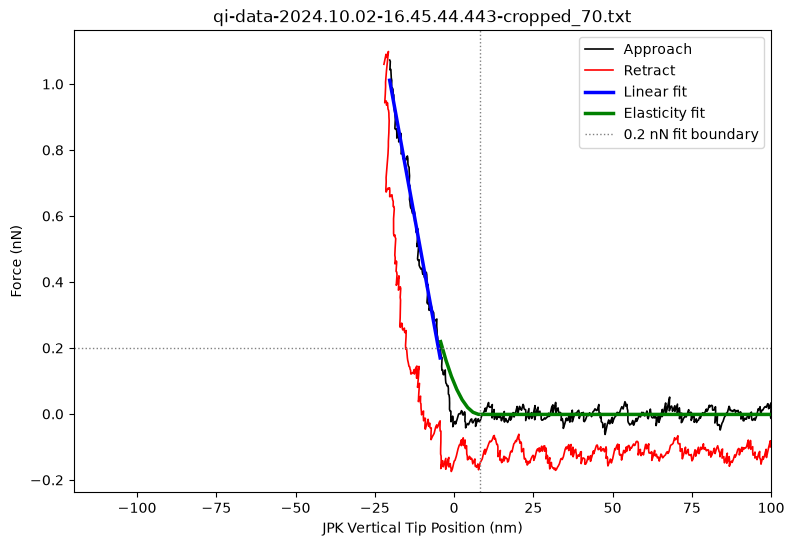

In [5]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# TEST SETTINGS
# ============================================================

AFM_FOLDER = Path("afm_data")

TEST_FOLDER = "-ve_cell1part1"

TEST_CURVE = 70

X_MIN = -120

X_MAX = 100

FORCE_BOUNDARY_NN = 0.2

POISSON_RATIO = 0.50

PYRAMID_HALF_ANGLE_DEG = 20.0


# ============================================================
# READ AFM TXT
# ============================================================

def load_afm_txt(file_path):

    segments = {}

    current_segment = None

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as file:

        for line in file:

            line = line.strip()

            if line.startswith("# segment:"):

                current_segment = (
                    line
                    .split(":", 1)[1]
                    .strip()
                    .lower()
                )

                segments.setdefault(
                    current_segment,
                    []
                )

                continue

            if not line:
                continue

            if line.startswith("#"):
                continue

            if current_segment is None:
                continue

            try:

                row = [
                    float(value)
                    for value in line.split()
                ]

            except ValueError:

                continue

            if len(row) >= 2:

                segments[
                    current_segment
                ].append(row)


    approach = np.asarray(
        segments.get("extend", []),
        dtype=float
    )

    retract = np.asarray(
        segments.get("retract", []),
        dtype=float
    )

    return approach, retract


# ============================================================
# READ TXT HEADER VALUE
# ============================================================

def read_header_value(
    file_path,
    key
):

    prefix = f"# {key}:"

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as file:

        for line in file:

            if line.startswith(prefix):

                return (
                    line
                    .split(":", 1)[1]
                    .strip()
                )

    return None


# ============================================================
# EXTRACT cropped NUMBER
# ============================================================

def get_cropped_number(name):

    match = re.search(
        r"cropped_(\d+)",
        str(name),
        re.IGNORECASE
    )

    if match is None:
        return None

    return int(
        match.group(1)
    )


# ============================================================
# FIND TXT
# ============================================================

folder = (
    AFM_FOLDER
    / TEST_FOLDER
)


test_files = sorted(
    folder.glob(
        f"*cropped_{TEST_CURVE}.txt"
    )
)


if len(test_files) == 0:

    raise FileNotFoundError(
        f"Curve {TEST_CURVE} not found in {folder}"
    )


txt_file = test_files[0]


print(
    "TXT:",
    txt_file
)


# ============================================================
# FIND MATCHING JPK TSV
# ============================================================

tsv_files = sorted(
    folder.glob(
        "*processed*.tsv"
    )
)


# Fallback search across afm_data
if len(tsv_files) == 0:

    acquisition_prefix = (
        txt_file.name
        .split("-cropped_", 1)[0]
    )

    tsv_files = [

        path

        for path
        in AFM_FOLDER.rglob(
            "*processed*.tsv"
        )

        if path.name.startswith(
            acquisition_prefix
        )

    ]


if len(tsv_files) == 0:

    raise FileNotFoundError(

        "No matching processed JPK TSV was found.\n"
        f"Put the batch TSV inside:\n{folder}"

    )


tsv_file = sorted(
    tsv_files
)[-1]


print(
    "TSV:",
    tsv_file
)


# ============================================================
# READ TXT CURVE
# ============================================================

approach, retract = (
    load_afm_txt(
        txt_file
    )
)


if approach.size == 0:

    raise ValueError(
        "No Extend segment found"
    )


# ============================================================
# READ SPRING CONSTANT
# ============================================================

kC_text = read_header_value(
    txt_file,
    "springConstant"
)


if kC_text is None:

    raise ValueError(
        "springConstant missing from TXT"
    )


kC = float(
    kC_text
)


# ============================================================
# READ JPK BATCH SUMMARY
# ============================================================

batch = pd.read_csv(
    tsv_file,
    sep="\t"
)


required = [

    "Filename",

    "Slope [N/m]",

    "Young's Modulus [Pa]",

    "Contact Point [m]",

    "Baseline [N]",

    "ResidualRMS [N]"

]


missing = [

    column

    for column
    in required

    if column not in batch.columns

]


if missing:

    raise ValueError(
        f"Missing TSV columns: {missing}"
    )


batch["_curve_number"] = (

    batch["Filename"]
    .apply(
        get_cropped_number
    )

)


matches = batch[

    batch[
        "_curve_number"
    ]
    == TEST_CURVE

]


if matches.empty:

    available = sorted(

        batch[
            "_curve_number"
        ]
        .dropna()
        .astype(int)
        .unique()
        .tolist()

    )

    raise ValueError(

        f"Curve {TEST_CURVE} is not present in the TSV.\n"
        f"Available TSV curves:\n{available}"

    )


row = matches.iloc[0]


# ============================================================
# JPK VALUES
# ============================================================

slope_jpk = abs(
    float(
        row[
            "Slope [N/m]"
        ]
    )
)


E_Pa = float(
    row[
        "Young's Modulus [Pa]"
    ]
)


contact_m = float(
    row[
        "Contact Point [m]"
    ]
)


baseline_N = float(
    row[
        "Baseline [N]"
    ]
)


rms_jpk_N = float(
    row[
        "ResidualRMS [N]"
    ]
)


# ============================================================
# APPROACH DATA
# ============================================================

x_m = approach[:, 0]

y_N = approach[:, 1]


x_nm = (
    x_m
    * 1e9
)


y_nN = (
    y_N
    * 1e9
)


# ============================================================
# RETRACT DATA
# ============================================================

x_retract_nm = (
    retract[:, 0]
    * 1e9
)


y_retract_nN = (
    retract[:, 1]
    * 1e9
)

# ============================================================
# DETERMINE JPK PROCESSED X OFFSET
# ============================================================

force_boundary_N = (
    FORCE_BOUNDARY_NN
    * 1e-9
)

nu = POISSON_RATIO

alpha_rad = np.deg2rad(
    PYRAMID_HALF_ANGLE_DEG
)

elasticity_coefficient = (
    0.7453
    * E_Pa
    / (1 - nu**2)
    * np.tan(alpha_rad)
)

finite = (
    np.isfinite(x_m)
    & np.isfinite(y_N)
)


def evaluate_shift(shift_nm):

    x_processed_m = (
        x_m
        + shift_nm * 1e-9
    )

    # Fit regions are selected along the force (y) axis.
    # Linear: 0.2 nN and above, naturally capped by the curve maximum.
    # Elasticity: below 0.2 nN, with no lower force cutoff.
    linear_mask = (
        finite
        & (y_N >= force_boundary_N)
    )

    elasticity_mask = (
        finite
        & (y_N < force_boundary_N)
    )

    # Need enough points for both fits
    if np.count_nonzero(linear_mask) < 20:
        return None

    if np.count_nonzero(elasticity_mask) < 20:
        return None


    # --------------------------------------------------------
    # Linear fit
    # --------------------------------------------------------

    linear_slope, linear_intercept = (
        np.polyfit(
            x_processed_m[linear_mask],
            y_N[linear_mask],
            1
        )
    )

    reconstructed_slope = abs(
        linear_slope
    )


    # --------------------------------------------------------
    # Elasticity prediction
    # --------------------------------------------------------

    delta_m = np.maximum(
        contact_m
        - x_processed_m[elasticity_mask],
        0.0
    )

    predicted_N = (
        baseline_N
        + elasticity_coefficient
        * delta_m**2
    )

    reconstructed_rms_N = np.sqrt(
        np.mean(
            (
                y_N[elasticity_mask]
                - predicted_N
            )**2
        )
    )


    # --------------------------------------------------------
    # Compare against JPK saved values
    # --------------------------------------------------------

    slope_relative_error = (
        abs(
            reconstructed_slope
            - slope_jpk
        )
        / slope_jpk
    )

    rms_relative_error = (
        abs(
            reconstructed_rms_N
            - rms_jpk_N
        )
        / rms_jpk_N
    )

    score = (
        slope_relative_error**2
        + rms_relative_error**2
    )

    return {
        "score": score,
        "slope": reconstructed_slope,
        "intercept": linear_intercept,
        "rms": reconstructed_rms_N,
        "linear_count": np.count_nonzero(
            linear_mask
        ),
        "elasticity_count": np.count_nonzero(
            elasticity_mask
        )
    }


# ============================================================
# COARSE SEARCH
# ============================================================

candidates = []

for shift_nm in np.arange(
    -300,
    300.01,
    0.5
):

    result = evaluate_shift(
        shift_nm
    )

    if result is not None:

        candidates.append(
            (
                result["score"],
                abs(shift_nm),
                shift_nm,
                result
            )
        )


if len(candidates) == 0:

    raise ValueError(
        "Could not determine a valid JPK x shift."
    )


candidates.sort(
    key=lambda item: (
        item[0],
        item[1]
    )
)

best_coarse_shift = (
    candidates[0][2]
)


# ============================================================
# FINE SEARCH
# ============================================================

fine_candidates = []

for shift_nm in np.arange(
    best_coarse_shift - 1.0,
    best_coarse_shift + 1.001,
    0.01
):

    result = evaluate_shift(
        shift_nm
    )

    if result is not None:

        fine_candidates.append(
            (
                result["score"],
                abs(shift_nm),
                shift_nm,
                result
            )
        )


fine_candidates.sort(
    key=lambda item: (
        item[0],
        item[1]
    )
)


best_shift_nm = (
    fine_candidates[0][2]
)

best_result = (
    fine_candidates[0][3]
)


print()
print(
    "Inferred JPK x shift:",
    round(best_shift_nm, 3),
    "nm"
)


# ============================================================
# CREATE JPK PROCESSED X COORDINATE
# ============================================================

x_processed_m = (
    x_m
    + best_shift_nm * 1e-9
)

x_processed_nm = (
    x_processed_m
    * 1e9
)


# Apply same x offset to retract curve
x_retract_processed_nm = (
    retract[:, 0] * 1e9
    + best_shift_nm
)

y_retract_nN = (
    retract[:, 1]
    * 1e9
)


# ============================================================
# FINAL LINEAR FIT
# ============================================================

linear_mask = (
    np.isfinite(x_processed_m)
    & np.isfinite(y_N)
    & (y_N >= force_boundary_N)
)


linear_slope, linear_intercept = (
    np.polyfit(
        x_processed_m[linear_mask],
        y_N[linear_mask],
        1
    )
)


linear_x_m = np.linspace(
    np.min(
        x_processed_m[linear_mask]
    ),
    np.max(
        x_processed_m[linear_mask]
    ),
    150
)


linear_y_N = (
    linear_slope
    * linear_x_m
    + linear_intercept
)


# ============================================================
# LINEAR R-SQUARED
# ============================================================

linear_prediction = (
    linear_slope
    * x_processed_m[linear_mask]
    + linear_intercept
)


ss_res = np.sum(
    (
        y_N[linear_mask]
        - linear_prediction
    )**2
)


ss_tot = np.sum(
    (
        y_N[linear_mask]
        - np.mean(
            y_N[linear_mask]
        )
    )**2
)


linear_r2 = (
    1
    - ss_res / ss_tot
)


# ============================================================
# kB
# ============================================================

kB_N_per_m = (
    kC
    * slope_jpk
    / (
        kC
        + slope_jpk
    )
)


kB_nN_per_um = (
    kB_N_per_m
    * 1000
)


# ============================================================
# ELASTICITY CURVE
#
# Visible over the x range of points below 0.2 nN.
# The fitting region itself has no lower y-force cutoff.
# ============================================================

elasticity_mask = (
    np.isfinite(x_processed_m)
    & np.isfinite(y_N)
    & (y_N < force_boundary_N)
)

elasticity_x_m = np.linspace(
    np.min(
        x_processed_m[elasticity_mask]
    ),
    np.max(
        x_processed_m[elasticity_mask]
    ),
    200
)


delta_m = np.maximum(
    contact_m
    - elasticity_x_m,
    0.0
)


elasticity_y_N = (
    baseline_N
    + elasticity_coefficient
    * delta_m**2
)


# ============================================================
# FINAL RMS VALIDATION
# ============================================================

rms_mask = (
    np.isfinite(x_processed_m)
    & np.isfinite(y_N)
    & (y_N < force_boundary_N)
)


delta_full_m = np.maximum(
    contact_m
    - x_processed_m[rms_mask],
    0.0
)


predicted_N = (
    baseline_N
    + elasticity_coefficient
    * delta_full_m**2
)


rms_reconstructed_N = np.sqrt(
    np.mean(
        (
            y_N[rms_mask]
            - predicted_N
        )**2
    )
)


# ============================================================
# PRINT VALIDATION
# ============================================================

print()

print(
    "Raw X range:",
    round(
        np.min(x_m) * 1e9,
        3
    ),
    "to",
    round(
        np.max(x_m) * 1e9,
        3
    ),
    "nm"
)


print(
    "Processed X range:",
    round(
        np.min(x_processed_m) * 1e9,
        3
    ),
    "to",
    round(
        np.max(x_processed_m) * 1e9,
        3
    ),
    "nm"
)


print()

print(
    "JPK slope:",
    slope_jpk,
    "N/m"
)


print(
    "Reconstructed slope:",
    abs(linear_slope),
    "N/m"
)


print(
    "Slope difference:",
    abs(
        abs(linear_slope)
        - slope_jpk
    ),
    "N/m"
)


print(
    "Linear R2:",
    linear_r2
)


print()

print(
    "kB:",
    kB_nN_per_um,
    "nN/um"
)


print(
    "E:",
    E_Pa / 1e6,
    "MPa"
)


print(
    "Contact point:",
    contact_m * 1e9,
    "nm"
)


print()

print(
    "JPK RMS:",
    rms_jpk_N * 1e12,
    "pN"
)


print(
    "Reconstructed RMS:",
    rms_reconstructed_N * 1e12,
    "pN"
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.plot(
    x_processed_nm,
    y_N * 1e9,
    color="black",
    linewidth=1.2,
    label="Approach"
)


ax.plot(
    x_retract_processed_nm,
    y_retract_nN,
    color="red",
    linewidth=1.2,
    label="Retract"
)


ax.plot(
    linear_x_m * 1e9,
    linear_y_N * 1e9,
    color="blue",
    linewidth=2.5,
    label="Linear fit"
)


ax.plot(
    elasticity_x_m * 1e9,
    elasticity_y_N * 1e9,
    color="green",
    linewidth=2.5,
    label="Elasticity fit"
)


ax.axhline(
    FORCE_BOUNDARY_NN,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="0.2 nN fit boundary"
)


ax.axvline(
    contact_m * 1e9,
    color="gray",
    linestyle=":",
    linewidth=1
)


ax.set_xlim(
    X_MIN,
    X_MAX
)


ax.set_xlabel(
    "JPK Vertical Tip Position (nm)"
)


ax.set_ylabel(
    "Force (nN)"
)


ax.set_title(
    txt_file.name
)


ax.legend()

plt.show()
